## Nelder-Mead Optimization

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import sys
import random
from tqdm import tqdm
from enum import Enum
from sklearn.metrics import mean_squared_error
sys.path.append('../../src')
from data_loader import DataLoader
from configs.configs import MeasurementDataEnum, SetupEnum, SamplingEnum, FilterEnum, ErrorEnum
from scipy.optimize import minimize
import scipy.stats as stats
from scipy.stats import multivariate_normal
from kalman_filters.extended_kalman_filter import ExtendedKalmanFilter
from kalman_filters.unscented_kalman_filter import UnscentedKalmanFilter
from kalman_filters.ensemble_kalman_filter import EnsembleKalmanFilter
from kalman_filters.particle_filter import ParticleFilter, ResamplingAlgorithms
from numpy.linalg import norm

%matplotlib inline
np.random.seed(777)

In [2]:
def objective(x):
    return x ** 2+2*np.sin(x*np.pi)

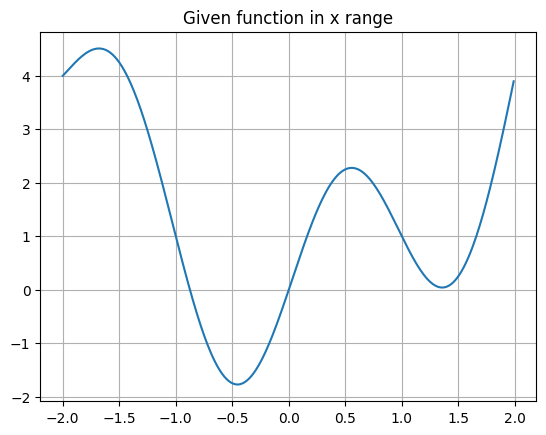

In [3]:
x = np.arange(-2, 2, 0.01)
y = objective(x)

plt.title("Given function in x range")
plt.plot(x, y)
plt.grid()
plt.show()

In [4]:
x0 = -1
result = minimize(objective, x0, method="nelder-mead")
print(result)

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -1.7730364463746562
             x: [-4.538e-01]
           nit: 15
          nfev: 30
 final_simplex: (array([[-4.538e-01],
                       [-4.539e-01]]), array([-1.773e+00, -1.773e+00]))


fun - the value of objective function

nfev - the number of evaluation

nit - the number of iterations

success - the existence of optimizer

x - the solution of the optimization

status - termination status

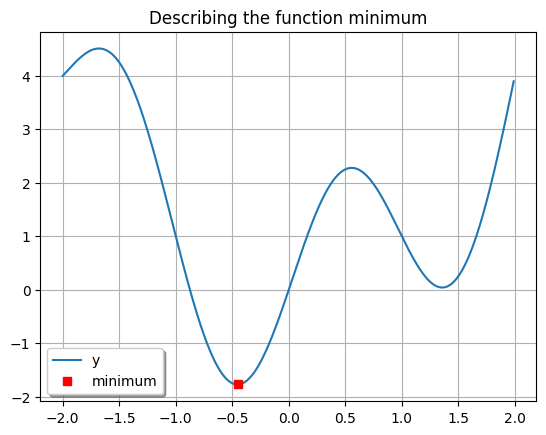

In [5]:
plt.title("Describing the function minimum")
plt.plot(x, y, label="y")
plt.plot(result['x'], result['fun'], 'sr', label="minimum")
plt.legend(loc='best', fancybox=True, shadow=True)
plt.grid()
plt.show()

The objective function that is shown in the Kalman Filter lecture is the following:

J = @(xy_model, xy_real) sum(sum((xy_real-xy_model).^2));

J_lkf = @(x) J(lkf_position_2d(pos_xy_m, dt, x(1:4), x(5:6)), pos_xy);

Data size: 1591
Shape:
GPS: (1591, 3)
VO: (1591, 3)
IMU: (1591, 6)
INS angle: (1591, 3)
INS velocity: (1591, 3)
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data
Adding noise to angle data
Data sampling is set to normal mode.


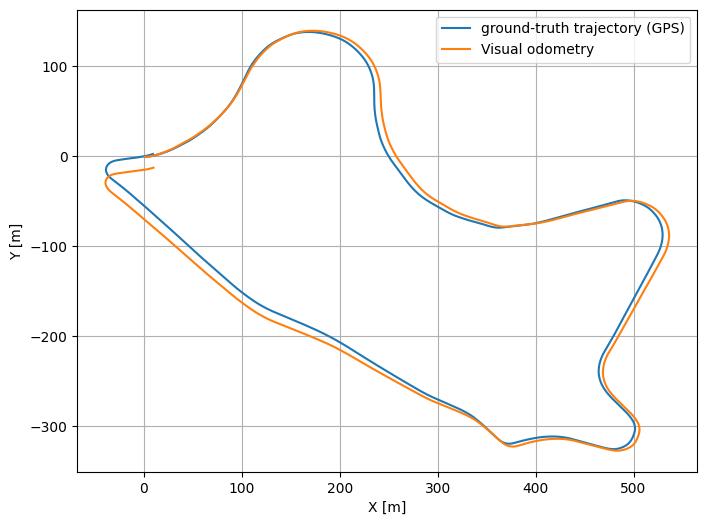

In [6]:
kitti_root_dir = '../../data'
vo_root_dir = '../../vo_estimates'
kitti_date = '2011_09_30'
kitti_drive = '0033'

data = DataLoader(sequence_nr=kitti_drive, 
                  kitti_root_dir=kitti_root_dir, 
                  vo_root_dir=vo_root_dir,
                  vo_dropout_ratio=0.0, 
                  gps_dropout_ratio=0.0,
                  visualize_data=True
                 )

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(setup=SetupEnum.SETUP_1, filter_type=FilterEnum.EKF)
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(setup=SetupEnum.SETUP_2, filter_type=FilterEnum.EKF)
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(setup=SetupEnum.SETUP_3, filter_type=FilterEnum.EKF)

In [11]:
def J(noise_vector):
    q_vo = noise_vector[:6]
    r_vo = noise_vector[6:8]
    r_vo = noise_vector[8:]
    ekf = ExtendedKalmanFilter(x=x_setup1.copy(), 
                               P=P_setup1.copy(), 
                               H=H_setup1.copy(),
                               q=q_vo,
                               r_vo=r_vo,
                               r_gps=r_vo,
                               setup=SetupEnum.SETUP_1
                               )
    ekf.run(data=data)
    estimated = ekf.get_estimated_trajectory()
    actual = data.GPS_measurements_in_meter[:, :2]
    return np.sum((actual - estimated) ** 2)

In [12]:
x0 = np.concatenate([q1, r_vo1, r_gps1]).tolist()

In [13]:
J(x0)

96552.24365839238

In [14]:
result = minimize(J, x0, method="nelder-mead")
print(result)

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 93612.61894253037
             x: [ 9.659e-01  9.686e-01  1.128e+00  1.291e+00  9.235e-01
                  1.259e+00  1.082e+00  9.126e-01  1.104e+00  1.182e-01]
           nit: 353
          nfev: 746
 final_simplex: (array([[ 9.659e-01,  9.686e-01, ...,  1.104e+00,
                         1.182e-01],
                       [ 9.659e-01,  9.686e-01, ...,  1.104e+00,
                         1.182e-01],
                       ...,
                       [ 9.659e-01,  9.686e-01, ...,  1.104e+00,
                         1.182e-01],
                       [ 9.659e-01,  9.686e-01, ...,  1.104e+00,
                         1.182e-01]]), array([ 9.361e+04,  9.361e+04,  9.361e+04,  9.361e+04,
                        9.361e+04,  9.361e+04,  9.361e+04,  9.361e+04,
                        9.361e+04,  9.361e+04,  9.361e+04]))


In [17]:
ekf_1 = ExtendedKalmanFilter(x=x_setup1.copy(), 
                               P=P_setup1.copy(), 
                               H=H_setup1.copy(),
                               q=q1,
                               r_vo=r_vo1,
                               r_gps=r_vo1,
                               setup=SetupEnum.SETUP_1
                               )
error_1 = ekf_1.run(data=data)

In [22]:
q1_optimal = result['x'][:6]
r_vo1_optimal = result['x'][6:8]
r_gps1_optimal = result['x'][8:]
ekf_1_optimal = ExtendedKalmanFilter(x=x_setup1.copy(), 
                               P=P_setup1.copy(), 
                               H=H_setup1.copy(),
                               q=q1_optimal,
                               r_vo=r_vo1_optimal,
                               r_gps=r_gps1_optimal,
                               setup=SetupEnum.SETUP_1
                               )
error_1_optimal = ekf_1_optimal.run(data=data)

[]

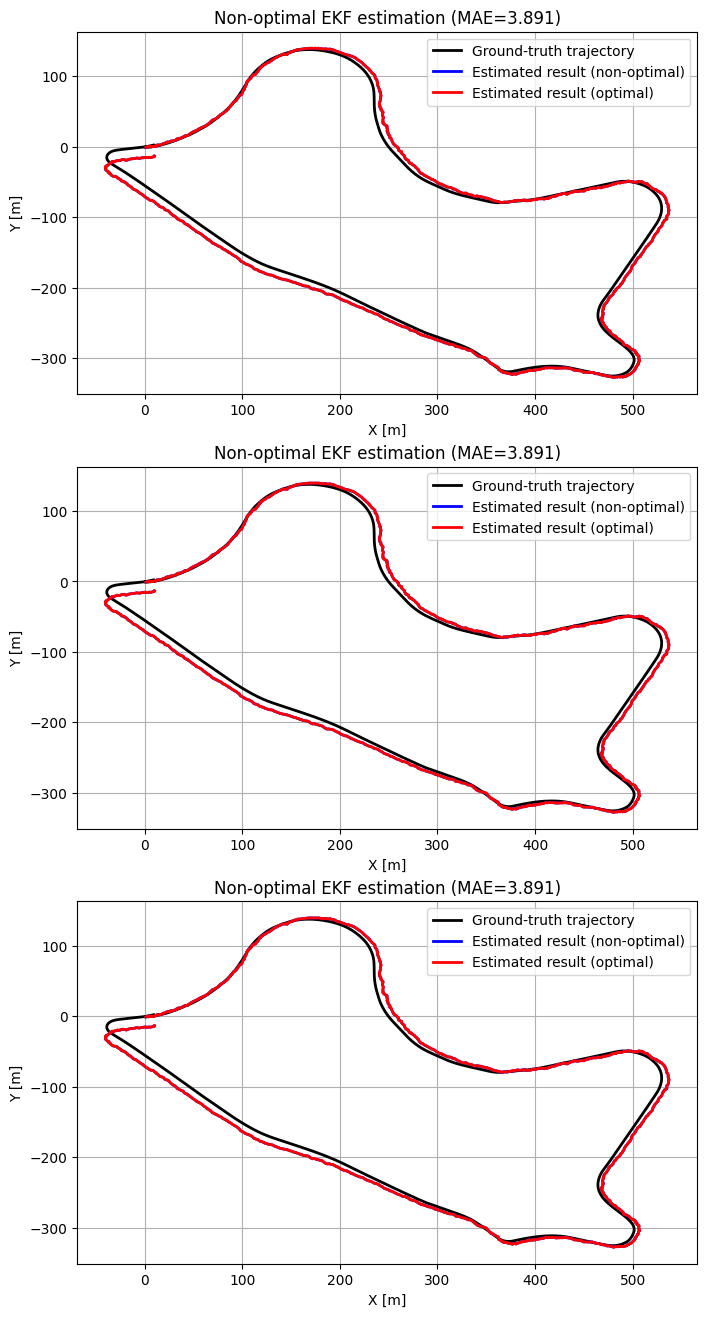

In [85]:
fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, ncols=1, figsize=(8, 16))
xs, ys, _ = data.GPS_measurements_in_meter.T

ax1.title.set_text(f'Non-optimal EKF estimation (MAE={error_1[ErrorEnum.MAE]})')
ax1.plot(xs, ys, lw=2, label='Ground-truth trajectory', color='black')
ax1.plot(ekf_1.mu_x, ekf_1.mu_y, lw=2, label='Estimated result (non-optimal)', color='b')
ax1.plot(ekf_1_optimal.mu_x, ekf_1_optimal.mu_y, lw=2, label='Estimated result (optimal)', color='r')
ax1.set_xlabel('X [m]')
ax1.set_ylabel('Y [m]')

ax2.title.set_text(f'Non-optimal EKF estimation (MAE={error_1[ErrorEnum.MAE]})')
ax2.plot(xs, ys, lw=2, label='Ground-truth trajectory', color='black')
ax2.plot(ekf_1.mu_x, ekf_1.mu_y, lw=2, label='Estimated result (non-optimal)', color='b')
ax2.plot(ekf_1_optimal.mu_x, ekf_1_optimal.mu_y, lw=2, label='Estimated result (optimal)', color='r')
ax2.set_xlabel('X [m]')
ax2.set_ylabel('Y [m]')

ax3.title.set_text(f'Non-optimal EKF estimation (MAE={error_1[ErrorEnum.MAE]})')
ax3.plot(xs, ys, lw=2, label='Ground-truth trajectory', color='black')
ax3.plot(ekf_1.mu_x, ekf_1.mu_y, lw=2, label='Estimated result (non-optimal)', color='b')
ax3.plot(ekf_1_optimal.mu_x, ekf_1_optimal.mu_y, lw=2, label='Estimated result (optimal)', color='r')
ax3.set_xlabel('X [m]')
ax3.set_ylabel('Y [m]')

ax1.legend()
ax1.grid()

ax2.legend()
ax2.grid()

ax3.legend()
ax3.grid()

plt.plot()

array([1.10412658, 0.11822663])

In [36]:
error_1_optimal

{<ErrorEnum.MAE: 1>: 3.89,
 <ErrorEnum.RMSE: 2>: 5.505,
 <ErrorEnum.MAX: 3>: 16.406}

In [37]:
error_1

{<ErrorEnum.MAE: 1>: 3.891,
 <ErrorEnum.RMSE: 2>: 5.508,
 <ErrorEnum.MAX: 3>: 16.45}

In [55]:
from utils.error_report import get_error_from_list
import pandas as pd

In [86]:
error_setup1 = [error_1, error_1_optimal]

In [106]:
mae_1 = np.array(get_error_from_list(error_setup1, e_type=ErrorEnum.MAE))
rmse_1 = np.array(get_error_from_list(error_setup1, e_type=ErrorEnum.RMSE))
max_1 = np.array(get_error_from_list(error_setup1, e_type=ErrorEnum.MAX))

In [107]:
mae_1 = np.append(mae_1, mae_1[1] - mae_1[0]).reshape(-1, 1)
rmse_1 = np.append(rmse_1, rmse_1[1] - rmse_1[0]).reshape(-1, 1)
max_1 = np.append(max_1, max_1[1] - max_1[0]).reshape(-1, 1)

In [108]:
setup1_error = np.concatenate([mae_1, rmse_1, max_1], axis=1)
setup1_error

array([[ 3.8910e+00,  5.5080e+00,  1.6450e+01],
       [ 3.8900e+00,  5.5050e+00,  1.6406e+01],
       [-1.0000e-03, -3.0000e-03, -4.4000e-02]])

In [109]:
errors = np.concatenate([setup1_error, setup1_error, setup1_error], axis=1)

In [110]:
header = pd.MultiIndex.from_product([['Setup1(IMU+VO)','Setup2(IMU+VO,GPS)', 'Setup3(INS)'],
                                   ["MAE", "RMSE", "MAX"]],
                                   names=['Setups', 'Error types'])
index = ["Non-optimized", "Optimized", "∆"]


In [111]:
df = pd.DataFrame(errors, index=index, columns=header)
df

Setups        Setup1(IMU+VO)                Setup2(IMU+VO,GPS)                 \
Error types              MAE   RMSE     MAX                MAE   RMSE     MAX   
Non-optimized          3.891  5.508  16.450              3.891  5.508  16.450   
Optimized              3.890  5.505  16.406              3.890  5.505  16.406   
∆                     -0.001 -0.003  -0.044             -0.001 -0.003  -0.044   

Setups        Setup3(INS)                 
Error types           MAE   RMSE     MAX  
Non-optimized       3.891  5.508  16.450  
Optimized           3.890  5.505  16.406  
∆                  -0.001 -0.003  -0.044

In [118]:
r = result['x'][:6]
r

array([0.96591706, 0.96863471, 1.12755911, 1.29072008, 0.92349325,
       1.25939961])

In [119]:
r[-2:]

array([0.92349325, 1.25939961])

In [120]:
r[-4:-2]

array([1.12755911, 1.29072008])

In [121]:
r[:-4]

array([0.96591706, 0.96863471])